# CNN Visual Walkthrough: From Pixels to Features

**Goal:** see what a CNN does to one MNIST digit, step by step. Run every cell in order.

## 1. Setup

We use PyTorch for tensors and CNN layers, `torchvision` to load MNIST, and Matplotlib for pictures.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using:', DEVICE)

Using: cpu


## 2. Load one real MNIST digit

MNIST contains 28 × 28 grayscale images. The number beside each image is its label.

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 377kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.84MB/s]

Tensor shape: torch.Size([1, 28, 28]) = (channels, height, width)


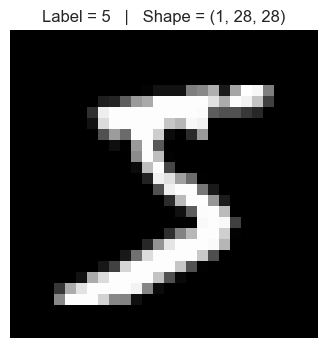

In [2]:
transform = transforms.ToTensor()  # changes pixels from 0–255 into 0–1
mnist = datasets.MNIST(root='data', train=True, download=True, transform=transform)
image, label = mnist[0]

plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Label = {label}   |   Shape = {tuple(image.shape)}')
plt.axis('off');
print('Tensor shape:', image.shape, '= (channels, height, width)')

## 3. Pixels are numbers

A grayscale image has one channel. White pixels are close to 1; black pixels are close to 0.

tensor([[0.0039, 0.6039, 0.9922, 0.3529, 0.0000],
        [0.0000, 0.5451, 0.9922, 0.7451, 0.0078],
        [0.0000, 0.0431, 0.7451, 0.9922, 0.2745],
        [0.0000, 0.0000, 0.1373, 0.9451, 0.8824],
        [0.0000, 0.0000, 0.0000, 0.3176, 0.9412]])


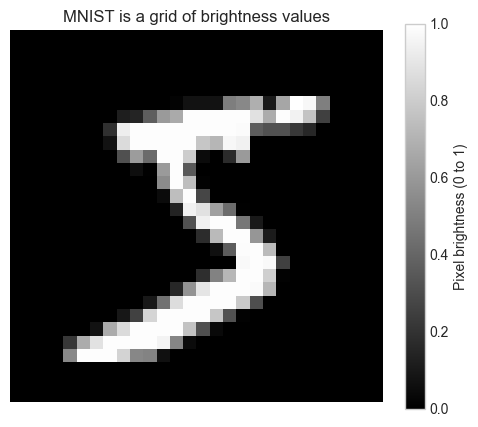

In [3]:
plt.figure(figsize=(6, 5))
plt.imshow(image.squeeze(), cmap='gray')
plt.colorbar(label='Pixel brightness (0 to 1)')
plt.title('MNIST is a grid of brightness values')
plt.axis('off');
print(image[0, 10:15, 10:15])

## 4. A hand-made filter

This 3 × 3 filter responds strongly to vertical edges. We are defining it by hand only to understand the idea.

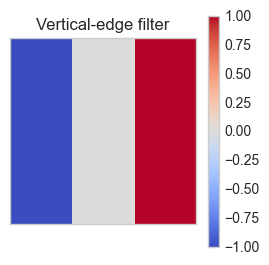

In [4]:
vertical_filter = torch.tensor([[[-1., 0., 1.],
                                 [-1., 0., 1.],
                                 [-1., 0., 1.]]]).unsqueeze(0)

plt.figure(figsize=(3, 3))
plt.imshow(vertical_filter.squeeze(), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(); plt.title('Vertical-edge filter'); plt.xticks([]); plt.yticks([]);

## 5. Convolution creates a feature map

The filter slides over the image. Its output is a new image called a **feature map**.

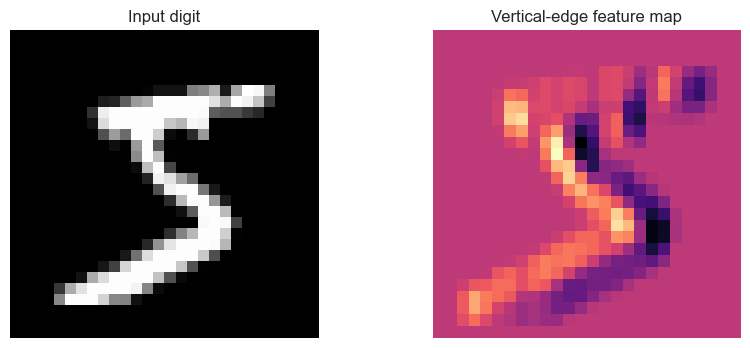

Feature-map shape: torch.Size([26, 26])


In [5]:
with torch.no_grad():
    feature_map = F.conv2d(image.unsqueeze(0), vertical_filter).squeeze()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(image.squeeze(), cmap='gray'); ax[0].set_title('Input digit'); ax[0].axis('off')
ax[1].imshow(feature_map, cmap='magma'); ax[1].set_title('Vertical-edge feature map'); ax[1].axis('off')
plt.show()
print('Feature-map shape:', feature_map.shape)

## 6. ReLU keeps useful positive signals

ReLU turns negative values into zero. This is the same activation function from the previous lesson.

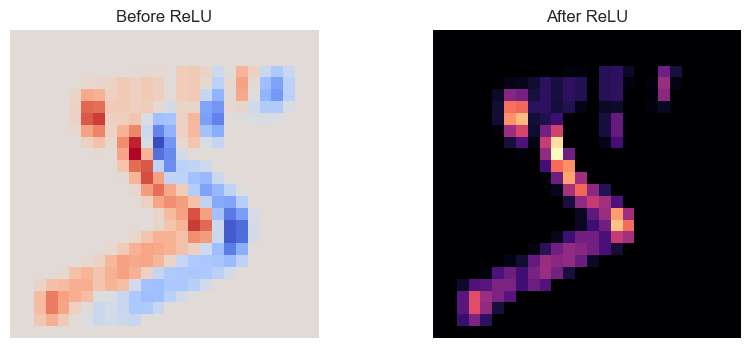

In [6]:
relu_map = F.relu(feature_map)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(feature_map, cmap='coolwarm'); ax[0].set_title('Before ReLU'); ax[0].axis('off')
ax[1].imshow(relu_map, cmap='magma'); ax[1].set_title('After ReLU'); ax[1].axis('off')
plt.show()

## 7. Max pooling makes the map smaller

Pooling keeps the strongest value in each small region. It reduces detail while keeping important clues.

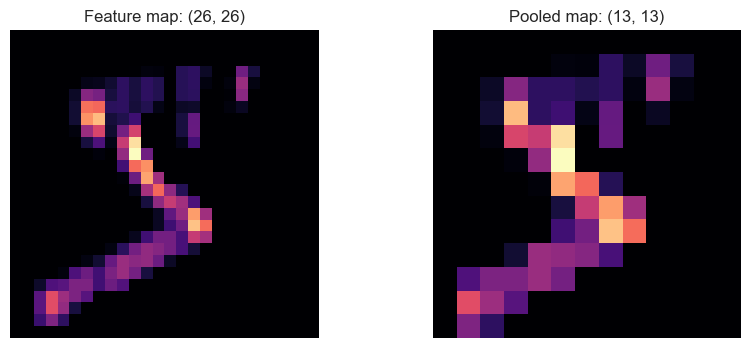

In [7]:
pooled_map = F.max_pool2d(relu_map.unsqueeze(0).unsqueeze(0), kernel_size=2).squeeze()
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(relu_map, cmap='magma'); ax[0].set_title(f'Feature map: {tuple(relu_map.shape)}'); ax[0].axis('off')
ax[1].imshow(pooled_map, cmap='magma'); ax[1].set_title(f'Pooled map: {tuple(pooled_map.shape)}'); ax[1].axis('off')
plt.show()

## 8. Many filters learn many clues

A real CNN learns filters automatically. Here we create four learned-looking feature maps using one convolution layer.

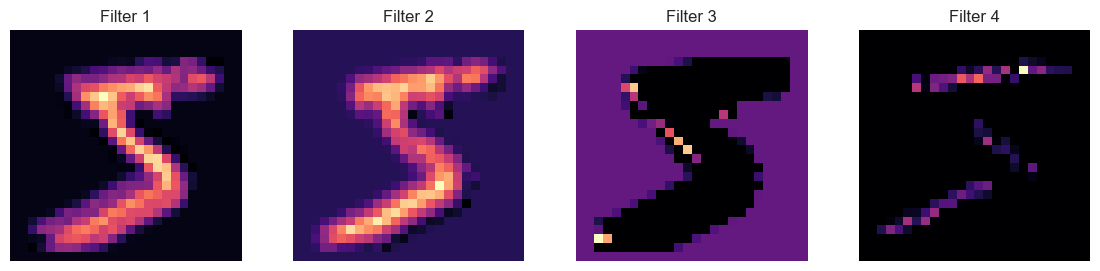

These filters are random now. Training changes them into useful detectors.


In [8]:
demo_layer = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3).to(DEVICE)
with torch.no_grad():
    learned_maps = F.relu(demo_layer(image.unsqueeze(0).to(DEVICE))).squeeze(0).cpu()

fig, ax = plt.subplots(1, 4, figsize=(14, 3))
for i in range(4):
    ax[i].imshow(learned_maps[i], cmap='magma')
    ax[i].set_title(f'Filter {i + 1}')
    ax[i].axis('off')
plt.show()
print('These filters are random now. Training changes them into useful detectors.')

## 9. The complete CNN idea

The next notebook trains this structure on MNIST. You do **not** need to memorize every line—follow the flow.

In [9]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Linear(16 * 5 * 5, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(start_dim=1)
        return self.classifier(x)

model = TinyCNN().to(DEVICE)
print(model)
print('Output shape:', model(image.unsqueeze(0).to(DEVICE)).shape, '= 10 scores, one for each digit')

TinyCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=400, out_features=10, bias=True)
)
Output shape: torch.Size([1, 10]) = 10 scores, one for each digit
